In [1]:
from pygeoinf import data_assimilation as da
import numpy as np
import matplotlib.pyplot as plt
from pygeoinf.data_assimilation.pendulum import double

plt.rcParams['animation.embed_limit'] = 100.0

In [85]:
# =============================================================================
# 1. PHYSICAL SETUP
# =============================================================================
# We define a standard double pendulum with equal lengths and masses. You can 
# later change these parameters if you wish. 
params = {"L1": 1.0, "L2": 1.0, "m1": 1.0, "m2": 1.0, "g": 1.0}

# Unpack for passing to the solver later
physics_args = (params["L1"], params["L2"], params["m1"], params["m2"], params["g"])


# =============================================================================
# 2. INITIAL CONDITIONS 
# =============================================================================
# The state vector is 4D: [theta1, theta2, p1, p2]
# Both angles measures from the downwards vertical direction. 
# p: Generalized momentum (related to angular velocity)

# TODO -- vary the initial conditions to put the systems in a higher energy state
theta1_init = np.deg2rad(20)
theta2_init = np.deg2rad(20)
p1_init = 0.0
p2_init = 0.0

# Create the state vector y0
y0 = np.array([theta1_init, theta2_init, p1_init, p2_init])

# TODO -- you can vary the size of the ensemble
n_ensemble = 10
forecast_duration = 40.0  # Seconds to forecast AFTER last observation

Generating synthetic data with 5 observation times...


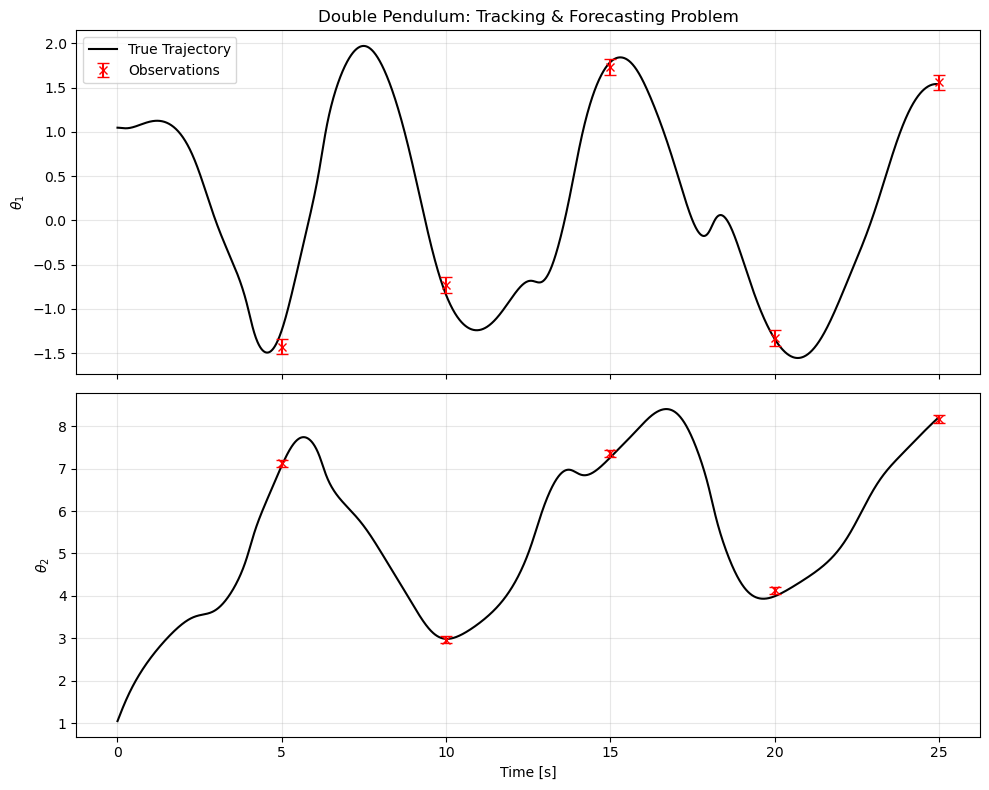

In [86]:
# 1. Physical Parameters
# We use the same standard double pendulum setup
params = {
    'L1': 1.0, 'L2': 1.0, 
    'm1': 1.0, 'm2': 1.0, 
    'g': 1.0
}

# 2. "True" Initial Condition
# TODO -- you can later vary these to see how the method performs
true_y0 = np.array([np.deg2rad(60), np.deg2rad(60), 2.0, 2.0]) # np.array([np.deg2rad(60), np.deg2rad(60), 0.0, 0.0])

# 3. Setup the Problem Manager
problem = da.BayesianAssimilationProblem(
    eom_func=double.eom,
    eom_args=(params['L1'], params['L2'], params['m1'], params['m2'], params['g'])
)

# 4. Define Observations (Multivariate)
# We observe BOTH angles (theta1, theta2) 

# TODO -- you can vary the number and spacing of the observations
n_obs = 5
dt_obs = 5

t_obs_points = np.linspace(
    dt_obs,
    dt_obs*n_obs, 
    n_obs
)

# Observation Noise (Standard Deviation)
# TODO -- you can vary the noise level, 
#         or set different errors for each 
#         observation 
obs_sigma = np.deg2rad(5)
R = np.diag([obs_sigma**2, obs_sigma**2])

# Observation Operator H (2x4)
# Maps state [th1, th2, p1, p2] -> observations [th1, th2]
# TODO -- you could consider different observations, for 
#         example, what if you only have measurements for one
#         of the bobs
H = np.array([
    [1.0, 0.0, 0.0, 0.0],  # Selects theta1
    [0.0, 1.0, 0.0, 0.0]   # Selects theta2
])

print(f"Generating synthetic data with {len(t_obs_points)} observation times...")

# Register observations
for t in t_obs_points:
    problem.add_observation(time=t, covariance=R, operator=H)

# 5. Generate Truth (with Forecast Window)
# We simulate past the last observation (up to 15s) to test forecasting.
truth_data = problem.generate_synthetic_data(
    true_initial_condition=true_y0,
    dt_render=0.01,    
)

# Extract data for plotting
t_true = truth_data['t_ground_truth']
y_true = truth_data['state_ground_truth']

# Extract observations
# Note: y_obs is now a vector of length 2 at each time step
obs_times = [t for t, _ in problem.observations]
obs_vals = np.array([m.y_obs for _, m in problem.observations]) # Shape (N_obs, 2)


# =============================================================================
# VISUALISATION: Truth vs Observations
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Theta 1
ax1.plot(t_true, y_true[0], 'k-', lw=1.5, label='True Trajectory')
ax1.errorbar(
    obs_times, obs_vals[:, 0], 
    yerr=obs_sigma, fmt='rx', capsize=4, label='Observations'
)
ax1.set_ylabel(r'$\theta_1$')
ax1.set_title('Double Pendulum: Tracking & Forecasting Problem')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot Theta 2
ax2.plot(t_true, y_true[1], 'k-', lw=1.5, label='True Trajectory')
ax2.errorbar(
    obs_times, obs_vals[:, 1], 
    yerr=obs_sigma, fmt='rx', capsize=4, label='Observations'
)
ax2.set_ylabel(r'$\theta_2$')
ax2.set_xlabel('Time [s]')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

Simulating 'Truth' up to t=65.0s...
Initializing 10 ensemble members...
Starting EnKF Assimilation...
Propagating 10 particles (4D system)...
Assimilated t=5.0s
Propagating 10 particles (4D system)...
Assimilated t=10.0s
Propagating 10 particles (4D system)...
Assimilated t=15.0s
Propagating 10 particles (4D system)...
Assimilated t=20.0s
Propagating 10 particles (4D system)...
Assimilated t=25.0s
Running Extended Forecast...
Propagating 10 particles (4D system)...


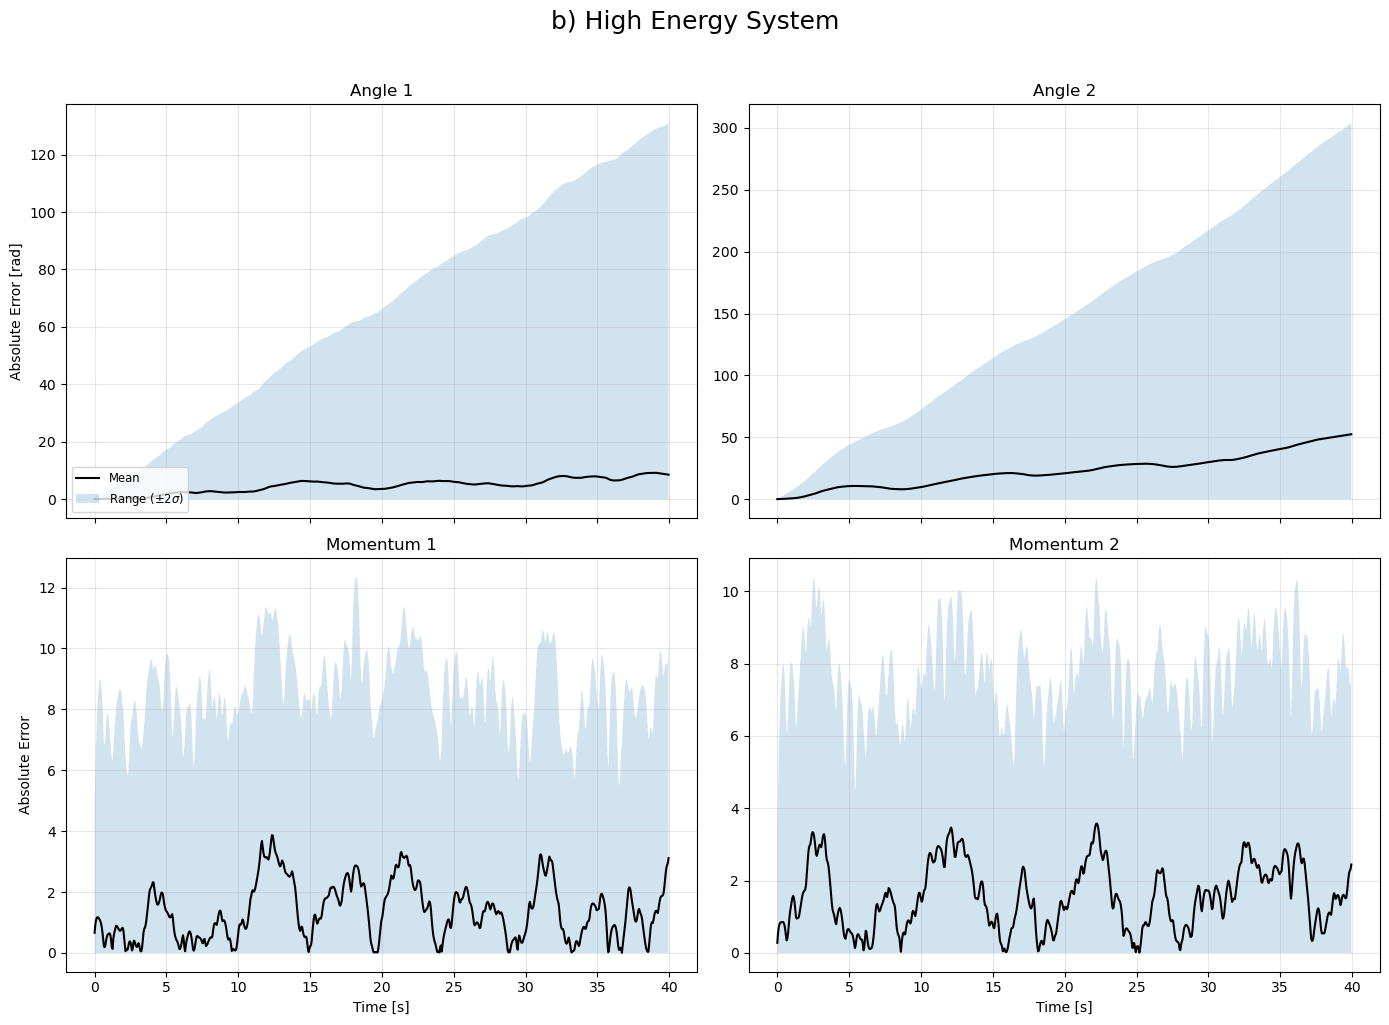

In [87]:
# 1. Configuration & Extended Truth
# ---------------------------------



# Determine timings based on the observations we generated earlier
t_last_obs = t_obs_points[-1]
t_final = t_last_obs + forecast_duration

# GENERATE EXTENDED TRUTH
# We re-run the true dynamics for the full duration (0 to t_final) so we have
# a "Ground Truth" to compare our forecast against.
print(f"Simulating 'Truth' up to t={t_final}s...")
t_true_full = np.arange(0, t_final, 0.05)
y_true_full = da.solve_trajectory(
    double.physics.eom,
    true_y0,
    t_true_full,
    args=physics_args
)

# 2. Initial Ensemble (The Prior)
# -------------------------------
print(f"Initializing {n_ensemble} ensemble members...")

# We start with a guess centered on the truth but with some spread
# TODO -- what happens if you change the prior to be more or less favorable? 
prior_mean = true_y0#+[0,0,0.5,0] # true_y0
prior_cov = np.diag([0.05**2, 0.05**2, 0.01**2, 0.01**2]) 

rng = np.random.default_rng(seed=42)
current_ensemble = rng.multivariate_normal(prior_mean, prior_cov, size=n_ensemble)


# 3. The Assimilation Loop (TODO)
# -------------------------------
t_current = 0.0
print("Starting EnKF Assimilation...")

# Loop over the observations we generated in Part 1
for t_obs, y_obs_k in zip(obs_times, obs_vals):
    
    dt_step = t_obs - t_current
    
    # =========================================================================
    # TODO STEP A: FORECAST
    # =========================================================================
    # Evolve the entire ensemble from t_current to t_obs using non-linear physics.
    # Hint: Use da.solve_ensemble(). It returns shape (N_ens, State_Dim, Time_Steps).
    # You only need the state at the final time step (index -1).

    solve_forecast = da.solve_ensemble(problem.eom_func, current_ensemble, (t_current, t_obs))
    
    # --- SOLUTION ---
    forecast_ensemble = solve_forecast[:,:,-1]
    # ----------------
    
    
    # =========================================================================
    # TODO STEP B: ANALYSIS
    # =========================================================================
    # Update the ensemble using the observation y_obs_k.
    
    analysis_ensemble = None
    
    if forecast_ensemble is not None:
        # 1. Perturb Observations
        # Create perturbed observations: y_p = y_obs + noise, where noise ~ N(0, R)
        # Hint: rng.multivariate_normal(np.zeros(2), R, size=n_ensemble)
        
        # obs_noise = ...
        # perturbed_obs = ...

        obs_noise = rng.multivariate_normal(np.zeros(2), R, size=n_ensemble)
        perturbed_obs = y_obs_k + obs_noise

        # 2. Compute Sample Covariance (Q) of the forecast
        # Hint: np.cov(forecast_ensemble, rowvar=False)
        
        # Q_sample = ...

        Q_sample = np.cov(forecast_ensemble, rowvar=False)
        
        # 3. Compute Kalman Gain (K)
        # Hint: S = H @ Q @ H.T + R
        # Hint: K = Q @ H.T @ np.linalg.inv(S)
        
        # K_gain = ...
        
        S = H @ Q_sample @ H.T + R
        K = Q_sample @ H.T @ np.linalg.inv(S)

        # 4. Update Ensemble Members
        # Hint: Loop over i in range(n_ensemble)
        # x_new = x_old + K * (y_perturbed - H * x_old)
        
        # --- SOLUTION ---
        analysis_ensemble = []
        
        for i in range(n_ensemble):

            x_old = forecast_ensemble[i]

            x_new = x_old.reshape(4, 1) + K.reshape(4, 2) @ (perturbed_obs[i].reshape (2, 1) - H.reshape(2, 4) @ x_old.reshape(4, 1))

            analysis_ensemble.append(x_new)

        analysis_ensemble = np.array(analysis_ensemble).reshape(n_ensemble, 4)

        # ----------------
        pass 

    # Safety Fallback if todo not implemented
    if analysis_ensemble is None: analysis_ensemble = current_ensemble

    # Store State
    current_ensemble = analysis_ensemble
    t_current = t_obs
    
    print(f"Assimilated t={t_current:.1f}s")


# 4. Forecast Beyond Data (TODO)
# ------------------------------
# Propagate the final analysis ensemble to 't_final'.

print("Running Extended Forecast...")

t_forecast = np.arange(t_current, t_final, 0.05)
final_forecast_traj = da.solve_ensemble(problem.eom_func, current_ensemble, t_forecast)

# --- SOLUTION ---

# ----------------


# 5. Visualisation (Full State: Angles & Momenta)
# -----------------------------------------------
# We compare the Forecast (Mean + Uncertainty) against the Extended Truth.

if final_forecast_traj is not None:
    
    # Calculate Forecast Statistics (Mean & Std Dev)
    ens_mean = np.mean(final_forecast_traj, axis=0) 
    ens_std  = np.std(final_forecast_traj, axis=0)

    # Create 2x2 grid for Angles and Momenta
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    
    plot_config = [
        (0, 0, r"$\theta_1$ [rad]", "Angle 1"),
        (0, 1, r"$\theta_2$ [rad]", "Angle 2"),
        (1, 0, r"$p_1$", "Momentum 1"),
        (1, 1, r"$p_2$", "Momentum 2")
    ]
    
    for row, col, ylabel, title in plot_config:
        state_idx = row * 2 + col
        ax = axes[row, col]
        
        n_forecast = len(t_forecast)
        shifted_forecast = t_forecast - t_forecast[0]

        forecast_error = y_true_full[state_idx][-n_forecast:] - ens_mean[state_idx]
        forecast_abs_error = np.abs(forecast_error)
        forecast_upper_error = forecast_abs_error + 2*ens_std[state_idx]
        forecast_lower_error = forecast_abs_error - 2*ens_std[state_idx]

        forecast_lower_error[forecast_lower_error < 0] = 0

        ax.plot(shifted_forecast, forecast_abs_error, 'k-', label='Mean')
        ax.fill_between(
            shifted_forecast,
            forecast_lower_error,
            forecast_upper_error,
            alpha=0.2,
            label=r'Range ($\pm 2\sigma$)'
        )

        ax.set_title(title)

        ax.grid(True, alpha=0.3)

        # Legend only on first plot
        if row == 0 and col == 0:
            ax.legend(loc='lower left', fontsize='small')
    

    axes[1, 0].set_xlabel("Time [s]")
    axes[1, 1].set_xlabel("Time [s]")
    axes[1, 0].set_ylabel('Absolute Error')
    axes[0, 0].set_ylabel('Absolute Error [rad]')
    
    plt.suptitle("b) High Energy System", y=1.02, fontsize=18)
    plt.tight_layout()
    plt.show()

we want a plot of forecast error against time

In [88]:
n_forecast = len(t_forecast)
shifted_forecast = t_forecast - t_forecast[0]

forecast_abs_error = np.abs(y_true_full[state_idx][-n_forecast:] - ens_mean[state_idx])

# 1. Plot WHOLE True Path (Context + Future)
# ax.plot(t_true_full[-n_forecast:], y_true_full[state_idx][-n_forecast:], 'k-', lw=1.5, label='True Path')

# 3. Plot Forecast Mean (In forecast range)
# ax.plot(t_forecast, ens_mean[state_idx], 'g--', lw=2, label='EnKF Forecast')

ax.plot(shifted_forecast, forecast_abs_error)

# 4. Plot Forecast Uncertainty (Shaded)
'''ax.fill_between(
    t_forecast, 
    ens_mean[state_idx] - 2*ens_std[state_idx], 
    ens_mean[state_idx] + 2*ens_std[state_idx], 
    color='green', alpha=0.2, label=r'Forecast Uncertainty ($2\sigma$)'
)'''

ax.set_xlabel('Forecast time (s)')
ax.set_ylabel('Absolute Error')

ax.grid(True, alpha=0.3)

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\nookh\AppData\Local\Temp\ipykernel_29088\762121248.py:15: SyntaxWarning: invalid escape sequence '\s'
  '''ax.fill_between(
